### Test power_iteration function

In [1]:
import numpy as np  
from svd_engine import power_iteration

In [2]:
M = np.array([[1, 2], [2, 4]])

In [3]:
eigenvalue, eigenvector = power_iteration(M, num_iterations=100)
print(eigenvalue)
print(eigenvector)

5.000000000000001
[0.4472136  0.89442719]


In [4]:
from svd_engine import deflation

In [5]:
M_deflated = deflation(M,eigenvalue,eigenvector)

In [6]:
print(M_deflated)

[[-10.18033989 -20.36067977]
 [ -9.18033989 -18.36067977]]


In [7]:
from svd_engine import eigen_decompose
M = np.array([[1, 2], [2, 4]])

In [8]:
print(eigen_decompose(M,2,100))

(array([ 5.00000000e+00, -2.22044605e-15]), array([[0.4472136 , 0.4472136 ],
       [0.89442719, 0.89442719]]))


In [9]:
import numpy as np  
from svd_engine import custom_svd,reconstruct_svd
M = np.array([[1, 2], [2, 4]])

In [10]:
# Pass M and the rank k (e.g., k=2) to custom_svd
U, sigma, Vt = custom_svd(M, k=6)
M_rec = reconstruct_svd(U, sigma, Vt)

In [13]:
# Calculate Frobenius norm of the difference matrix
loss = np.linalg.norm(M - M_rec)
# MSE
mean_loss = np.mean((M - M_rec) ** 2)
# Reconstruction loss
norm_loss = np.linalg.norm(M - M_rec) / np.linalg.norm(M)


In [14]:
print(loss)
print(mean_loss)
print(norm_loss)


4.999999999999999
6.249999999999997
0.9999999999999998


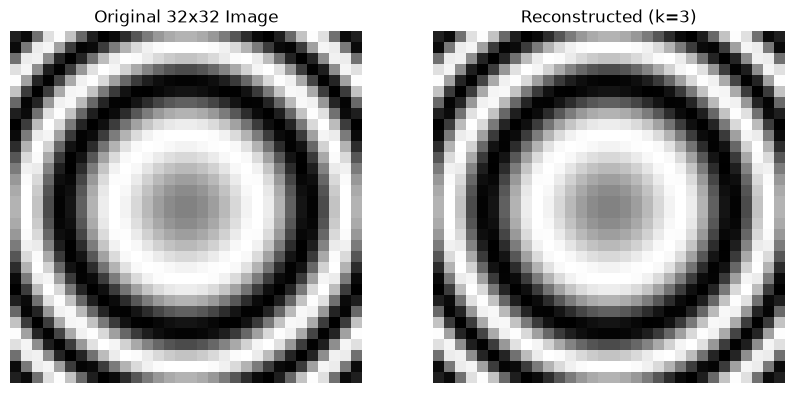

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from svd_engine import custom_svd, reconstruct_svd

# 1. Create a 32x32 synthetic grayscale image (a simple 2D pattern)
x = np.linspace(-3, 3, 32)
y = np.linspace(-3, 3, 32)
X, Y = np.meshgrid(x, y)
# Create a radial wave pattern, scaled to [0, 1]
original_img = (np.sin(X**2 + Y**2) + 1) / 2.0 

# 2. Perform Custom SVD (We will keep the top 8 singular values)
k = 3
U, sigma, Vt = custom_svd(original_img, k=k)

# 3. Reconstruct the image
reconstructed_img = reconstruct_svd(U, sigma, Vt)

# 4. Display both images side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot Original
axes[0].imshow(original_img, cmap='gray')
axes[0].set_title("Original 32x32 Image")
axes[0].axis("off")

# Plot Reconstructed
axes[1].imshow(reconstructed_img, cmap='gray')
axes[1].set_title(f"Reconstructed (k={k})")
axes[1].axis("off")

plt.show()


In [16]:
import numpy as np
from svd_engine import custom_svd   # returns U, sigma, Vt

# 32×32 test matrix (the one you used in the notebook cell)
x = np.linspace(-3, 3, 32)
y = np.linspace(-3, 3, 32)
X, Y = np.meshgrid(x, y)
M = (np.sin(X**2 + Y**2) + 1) / 2.0   # values in [0,1]

# Compute *full* SVD (k = 32) to get every singular value
_, full_sigma, _ = custom_svd(M, k=32)

# Print singular values and cumulative energy
total_energy = np.sum(full_sigma**2)
cumulative = np.cumsum(full_sigma**2) / total_energy * 100

print("Singular values (descending):")
print(full_sigma.round(4))
print("\nCumulative energy (% of total) after each singular value:")
for i, pct in enumerate(cumulative, start=1):
    print(f"  k={i:2d}: {pct:6.2f}%")


Singular values (descending):
[18.6818  6.9605  6.0571  0.      0.      0.      0.      0.      0.
  0.      0.      0.      0.      0.      0.      0.      0.      0.
  0.      0.      0.      0.      0.      0.      0.      0.      0.
  0.      0.      0.      0.      0.    ]

Cumulative energy (% of total) after each singular value:
  k= 1:  80.39%
  k= 2:  91.55%
  k= 3: 100.00%
  k= 4: 100.00%
  k= 5: 100.00%
  k= 6: 100.00%
  k= 7: 100.00%
  k= 8: 100.00%
  k= 9: 100.00%
  k=10: 100.00%
  k=11: 100.00%
  k=12: 100.00%
  k=13: 100.00%
  k=14: 100.00%
  k=15: 100.00%
  k=16: 100.00%
  k=17: 100.00%
  k=18: 100.00%
  k=19: 100.00%
  k=20: 100.00%
  k=21: 100.00%
  k=22: 100.00%
  k=23: 100.00%
  k=24: 100.00%
  k=25: 100.00%
  k=26: 100.00%
  k=27: 100.00%
  k=28: 100.00%
  k=29: 100.00%
  k=30: 100.00%
  k=31: 100.00%
  k=32: 100.00%


In [18]:
import numpy as np
from image_pipeline import load_image

In [20]:
import os
print(os.getcwd())


c:\Users\deves\Downloads\projects\ai-projects-collection\High-Resolution SVD Image Compressor\src


In [21]:
image = load_image('..\samples\image.jpg')


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\deves\AppData\Local\Temp\ipykernel_11928\3814579901.py:1: SyntaxWarning: invalid escape sequence '\s'
  image = load_image('..\samples\image.jpg')


In [22]:
print(image)

[[[0.36078431 0.34509804 0.30196078]
  [0.36078431 0.34509804 0.30196078]
  [0.36078431 0.34509804 0.30196078]
  ...
  [0.38039216 0.36078431 0.3372549 ]
  [0.38039216 0.36078431 0.3372549 ]
  [0.38039216 0.36078431 0.3372549 ]]

 [[0.36078431 0.34509804 0.30196078]
  [0.36078431 0.34509804 0.30196078]
  [0.36078431 0.34509804 0.30196078]
  ...
  [0.38039216 0.36078431 0.3372549 ]
  [0.38039216 0.36078431 0.3372549 ]
  [0.38039216 0.36078431 0.3372549 ]]

 [[0.36470588 0.34901961 0.30588235]
  [0.36470588 0.34901961 0.30588235]
  [0.36470588 0.34901961 0.30588235]
  ...
  [0.38039216 0.36078431 0.3372549 ]
  [0.38039216 0.36078431 0.3372549 ]
  [0.38039216 0.36078431 0.3372549 ]]

 ...

 [[0.26666667 0.23529412 0.19215686]
  [0.26666667 0.23529412 0.19215686]
  [0.26666667 0.23529412 0.19215686]
  ...
  [0.36470588 0.30196078 0.2       ]
  [0.36470588 0.30196078 0.2       ]
  [0.36470588 0.30196078 0.2       ]]

 [[0.26666667 0.23529412 0.19215686]
  [0.26666667 0.23529412 0.19215686]


In [23]:
print(image.shape)
print(image.dtype)
print(image.min(), image.max())

(4318, 7680, 3)
float64
0.0 1.0
